<span style="color:gray">Aprendizaje Máquina >> Aprendizaje Supervisado >> Clasificación >> KNN</span>
<h1 style="margin-top:0px;">K-NN K-Nearest Neighbors (K-Vecinos más cercanos)</h1>
K vecinos más cercanos es uno de los algoritmos de clasificación más básicos y esenciales en Machine Learning. Pertenece al dominio del aprendizaje supervisado y encuentra una aplicación intensa en el reconocimiento de patrones, la minería de datos y la detección de outliers.
<p>Es un clasificador robusto y versátil que a menudo se usa como un punto de referencia para clasificadores más complejos como las <span style="color:red">redes neuronales artificiales y maquinas de soporte vectorial(SVM)</span>. A pesar de su simplicidad, KNN puede superar a los clasificadores más potentes y se usa en una variedad de aplicaciones tales como pronósticos económicos, compresión de datos y genética.</p>
<p>Este algoritmo consiste en seleccionar un valor de K. Al momento del análisis los K datos más cercanos al valor que se desea predecir será la solución.</p>
<p>Acá lo importante es seleccionar un valor de K acorde a los datos para tener una mayor precisión en la predicción.</p>
<img src="img/knn.jpg" width="450" style="margin:0 auto;" />
Es un algoritmo no paramétrico y basado en instancias.
<ul>
    <li><b>No paramétrico</b> significa que no hace suposiciones explícitas sobre la forma funcional de los datos, evitando modelar mal la distribución subyacente de los datos. Por ejemplo, supongamos que nuestros datos son altamente no gaussianos, pero el modelo de Machine Learning que elegimos asume una <span style="color:red">forma gaussiana</span>. En este caso, nuestro algoritmo haría predicciones extremadamente pobres.</li>
    <li>El aprendizaje basado en la <b>instancia</b> significa que nuestro algoritmo no aprende explícitamente un modelo. En lugar de ello, opta por memorizar las instancias de formación que posteriormente se utilizan como “conocimiento” para la fase de predicción. Concretamente, esto significa que solo cuando se realiza una consulta a nuestra base de datos, es decir, cuando le pedimos que predique una etiqueta con una entrada, el algoritmo utilizará las instancias de formación para dar una respuesta.</li>
</ul>
<p>Cabe señalar que la fase de formación mínima de KNN se realiza tanto a un coste de memoria, ya que debemos almacenar un conjunto de datos potencialmente enorme durante el tiempo de prueba, ya que la clasificación de una observación determinada requiere un agotamiento de todo el conjunto de dato. En la práctica, esto no es deseable, ya que normalmente queremos respuestas rápidas.</p>

<h2>Representación matemática de K Vecinos más Cercanos</h2>
Supongamos que Z (punto verde) es el punto que se necesita predecir. Primero, se encuentran los K puntos más cercano a Z y luego se clasifican los puntos para el voto mayoritario de sus vecinos K. Cada objeto vota por su clase y la clase con más votos se toma como la predicción. Para encontrar los puntos similares más cercanos, se encuentra la distancia entre puntos utilizando <span style="color:red">medidas de distancias</span>.
<img src="img/knn_ejemplo.jpg" width="450" style="margin:0 auto;" />
Una opción popular es la distancia <b>euclidiana</b>, pero también hay otras medidas que pueden ser más adecuadas para un entorno dado e incluyen la distancia de <span style="color:red">Mahattan y Minkowski</span>.
<img src="img/distancias.jpg" width="450" style="margin:0 auto;" />
En resumen, KNN tiene los siguientes pasos básicos:
<ul>
    <li>Calcular las distancias</li>
    <li>Encontrar sus k vecinos más cercanos</li>
    <li>Votar por las etiquetas</li>
</ul>

<h2>¿Cómo se decide el número de vecinos en KNN?</h2>
Ya que conocemos cómo funciona este algoritmo, es momento de saber cómo se define K. El número de vecinos (K) es un hiperparámetro que se debe elegir en el momento de la construcción del modelo. Puedes pensar en K como una variable de control para el modelo de predicción.
<p>La investigación ha demostrado que no existe un número óptimo de vecinos que se adapte a todo tipo de conjuntos de datos. Cada conjunto de datos tiene sus propios requisitos. Se ha demostrado que una pequeña cantidad de vecinos son los más flexibles, que tendrán un bajo sesgo, pero una alta varianza, y un gran número de vecinos tendrán un límite de decisión más suave, lo que significa una varianza más baja pero un sesgo más alto.</p>
<p>Generalmente, se recomienda elegir un número impar si el número de clases es par. También puede comprobar generando el modelo en diferentes valores de K y comprobar su rendimiento.</p>
<h2>Ventajas</h2>
<ul>
    <li><b>No paramétrico.</b> No hace suposiciones explícitas sobre la forma funcional de los datos, evitando los peligros de la distribución subyacente de los datos.
    <li><b>Algoritmo simple</b>. Para explicar, comprender e interpretar.
    <li><b>Alta precisión</b> (relativa). Es bastante alta pero no competitiva en comparación con modelos de aprendizaje mejor supervisados.
    <li><b>Insensible a los valores atípicos</b>. La precisión puede verse afectada por el ruido o las características irrelevantes.
</ul>

<h2>Desventajas</h2>
<ul>
    <li><b>Basado en instancia</b>. El algoritmo no aprende explícitamente un modelo, en su lugar, elige memorizar las instancias de capacitación que se utilizan posteriormente como conocimiento para la fase de predicción. Concretamente, esto significa que solo cuando se realiza una consulta a nuestra base de datos, es decir cuando le pedimos que prediga una etiqueta dada una entrada, el algoritmo usará las instancias de entrenamiento para escupir una respuesta.</li>
    <li><b>Computacionalmente costoso</b>. Porque el algoritmo almacena todos los datos de entrenamiento.</li>
    <li><b>Requisito de memoria alta</b>. Almacena todos (o casi todos) los datos de entrenamiento.</li>
</ul>

<h2>Ejemplo</h2>
<h3>Librerias</h3>

In [1]:
import tarfile
import urllib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, r2_score, mean_squared_error, classification_report, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

<h3>Extracción del repositorio</h3>
El siguiente código descarga y lee el dataset directamente del archivo comprimido .tar.gz<br/>
Otra opción es descargar el repositorio manualmente, descomprimirlo y usar pd.<span style="color:green">read_csv</span>()

In [2]:
uci_tcga_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00401/"
)
archive_name = "TCGA-PANCAN-HiSeq-801x20531.tar.gz"

# build the url
full_download_url = urllib.parse.urljoin(uci_tcga_url, archive_name)

# download the file
r = urllib.request.urlretrieve(full_download_url, archive_name)

# extract the data from the archive
tar = tarfile.open(archive_name, "r:gz")
tar.extractall()
tar.close()

In [3]:
datafile = "TCGA-PANCAN-HiSeq-801x20531/data.csv"
labels_file = "TCGA-PANCAN-HiSeq-801x20531/labels.csv"
data = np.genfromtxt(
    datafile, delimiter=",", usecols=range(1, 20532), skip_header=1
)
true_label_names = np.genfromtxt(
    labels_file, delimiter=",", usecols=(1,), skip_header=1, dtype=str
)

In [4]:
data[:5, :3]

array([[0.        , 2.01720929, 3.26552691],
       [0.        , 0.59273209, 1.58842082],
       [0.        , 3.51175898, 4.32719872],
       [0.        , 3.66361787, 4.50764878],
       [0.        , 2.65574107, 2.82154696]])

In [5]:
data.shape

(801, 20531)

In [6]:
true_label_names[:5]

array(['PRAD', 'LUAD', 'PRAD', 'PRAD', 'BRCA'], dtype='<U4')

<p>Las variables del dataset contiene todos los valores de expresión génica de 20.531 genes. Los true_label_names son los tipos de cáncer para cada una de las 881 muestras. El primer registro en data corresponde con la primera etiqueta en true_labels.</p>
<p>Las etiquetas son cadenas que contienen abreviaturas de tipos de cáncer:
<ul>
    <li><b>BRCA</b>: Carcinoma invasivo de mama (breast)</li>
    <li><b>COAD</b>: adenocarcinoma de colon</li>
    <li><b>KIRC</b>: Carcinoma renal de células claras de riñón (kidney)</li>
    <li><b>LUAD</b>: adenocarcinoma de pulmón (lung)</li>
    <li><b>PRAD</b>: adenocarcinoma de próstata (prostate)</li>
</ul>
Para usar estas etiquetas en los métodos de evaluación, primero debe convertir las abreviaturas a números enteros con LabelEncoder:

In [7]:
#Codificación de categorias a números
label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(true_label_names)
true_labels[:5]

array([4, 3, 4, 4, 0])

Como label_encoder se ha ajustado a los datos, puede ver las clases únicas representadas mediante <span style="color:green">.classes_</span>. Almacene la longitud de la matriz en la variable <span style="color:green">n_clusters</span> para su uso posterior:

In [8]:
label_encoder.classes_

array(['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD'], dtype='<U4')

<H3>Escalar los datos</h3>

In [9]:
scaler_minmax=MinMaxScaler()
X= scaler_minmax.fit_transform(data)
X[:5, :3]

array([[0.        , 0.32342445, 0.53855624],
       [0.        , 0.09503429, 0.26196506],
       [0.        , 0.56304952, 0.71364896],
       [0.        , 0.58739745, 0.74340909],
       [0.        , 0.42580192, 0.46533432]])

<h4>Analisis de componentes principales PCA</h4>

<p>Las técnicas de <span style="color:red">reducción de la dimensionalidad</span> ayudan a abordar un problema con los algoritmos de aprendizaje automático conocido como la maldición de la dimensionalidad. En resumen, a medida que aumenta el número de características, el espacio de características se vuelve escaso. Esta escasez dificulta que los algoritmos encuentren objetos de datos cerca uno del otro en un espacio de mayor dimensión. Dado que el conjunto de datos de expresión génica tiene más de 20 000 características, califica como un gran candidato para la reducción de la dimensionalidad.</p>
<p>El <span style="color:red">análisis de componentes principales (PCA)</span> transforma los datos de entrada proyectándolos en un número menor de dimensiones llamadas componentes. Los componentes capturan la variabilidad de los datos de entrada a través de una combinación lineal de las características de los datos de entrada.</p>

In [10]:
pca=PCA(n_components=7) # del ejercicio de PCA
pca.fit(X) # obtener los componentes principales
X_pca=pca.transform(X) # convertimos nuestros datos con las nuevas dimensiones de PCA

print("shape of X_pca", X_pca.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:6]))

shape of X_pca (801, 7)
[0.12693977 0.09402273 0.08575765 0.05587808 0.0477173  0.02783274
 0.02401653]
suma: 0.4381482721521773


<H3>Separamos el dataset en entrenamiento y pruebas</H3>

In [11]:
X_pca.shape[0]*0.8

640.8000000000001

In [12]:
Xtrain=X_pca[:641,:7]
Xtrain[:5,:7]

array([[ -5.66814062,  -8.87213882,  15.8532898 ,  -6.65990853,
          3.24488198,   3.52986634,  -0.18662876],
       [ -1.47020396,  10.2801817 ,  -1.24663377,  -1.59727719,
         -5.05363869,   5.3299758 ,  -3.21345747],
       [-10.84538683,  -1.34535223,   4.0007703 ,   8.01046682,
          3.52030381,   6.4399376 ,  -2.00837379],
       [ -9.16796108,  -8.67012319,   5.48148324,   5.50531062,
         -0.45323241,   4.09816981,  -2.68758141],
       [ -6.27184805,  -3.10120757,  -7.33897606,   0.43354024,
          4.29082362,  -0.31674531,  -0.30697321]])

In [13]:
Xtest=X_pca[642:800,:7]
Ytrain=true_labels[:641]
Ytest=true_labels[642:800]

In [14]:
#si en lugar de array multiple fuera dataframe
#X = df_breast_cancer.drop('target',axis=1)
#Y = df_breast_cancer['target']
#Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y.values.reshape(-1,1),test_size=0.2, random_state=42)

<h3>Creamos el modelo</h3>

In [15]:
#instanciamos el algoritmo con los parámetros elegido
modelo = KNeighborsClassifier(n_neighbors=3,
                                  algorithm='brute',
                                  p=1,
                                  weights='distance',
                                  n_jobs=-1)

<h4>Lo entrenamos</h4>

In [16]:
#Entrenamos el algoritmo
modelo.fit(Xtrain,Ytrain)

KNeighborsClassifier(algorithm='brute', n_jobs=-1, n_neighbors=3, p=1,
                     weights='distance')

<h4>Probamos el modelo</h4>

In [17]:
#Predecimos el test y utilizamos métricas de clasificacion para comprobar nuestros modelos en Train
preds_test = modelo.predict(Xtest)
print('CLASSIFICATION IN TRAIN')
print("----------------------------------------")
print('CONFUSION MATRIX:\n', confusion_matrix(preds_test, Ytest))
print("----------------------------------------")
#print('F1 SCORE:\n', f1_score(preds_test, Ytest))
print("----------------------------------------")
print('CLASSIFICATION REPORT\n',classification_report(preds_test, Ytest))

CLASSIFICATION IN TRAIN
----------------------------------------
CONFUSION MATRIX:
 [[59  0  0  0  0]
 [ 0 13  0  0  0]
 [ 0  0 31  0  0]
 [ 0  1  0 27  0]
 [ 0  0  0  0 27]]
----------------------------------------
----------------------------------------
CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.93      1.00      0.96        13
           2       1.00      1.00      1.00        31
           3       1.00      0.96      0.98        28
           4       1.00      1.00      1.00        27

    accuracy                           0.99       158
   macro avg       0.99      0.99      0.99       158
weighted avg       0.99      0.99      0.99       158



In [18]:
preds_test

array([0, 2, 3, 3, 2, 2, 3, 2, 1, 0, 1, 2, 0, 0, 4, 4, 4, 3, 4, 4, 1, 0,
       0, 1, 3, 2, 0, 2, 1, 0, 0, 0, 4, 3, 2, 0, 4, 2, 4, 0, 3, 2, 4, 3,
       4, 4, 0, 2, 4, 3, 1, 1, 0, 0, 0, 3, 2, 2, 2, 0, 3, 2, 4, 0, 3, 4,
       0, 4, 0, 2, 0, 1, 4, 4, 2, 4, 2, 0, 3, 3, 0, 0, 2, 0, 0, 0, 0, 2,
       2, 4, 1, 2, 0, 0, 2, 0, 3, 0, 0, 4, 0, 4, 0, 1, 0, 0, 2, 3, 0, 0,
       4, 0, 4, 1, 0, 0, 0, 3, 0, 3, 0, 3, 2, 2, 1, 1, 0, 0, 0, 3, 0, 3,
       2, 0, 3, 2, 3, 3, 3, 2, 0, 4, 0, 0, 2, 0, 4, 2, 0, 0, 0, 0, 4, 3,
       0, 3, 3, 4])

<h4>Comparamos la agrupación original con la agrupación de K-means</h4>

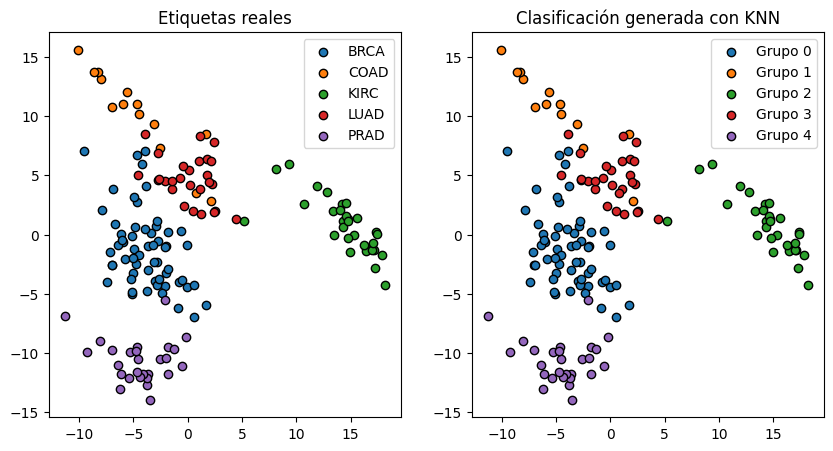

In [19]:
# Clasificación con el modelo KNN
# ==============================================================================
true_labels_test=true_labels[642:800]

# Representación gráfica: grupos originales vs clusters creados
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Grupos originales
for i in np.unique(true_labels):
    ax[0].scatter(
        x = Xtest[true_labels_test == i, 0],
        y = Xtest[true_labels_test == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= label_encoder.classes_[i]
    )
ax[0].set_title('Etiquetas reales')
ax[0].legend();

for i in np.unique(preds_test):
    ax[1].scatter(
        x = Xtest[preds_test == i, 0],
        y = Xtest[preds_test == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )

ax[1].set_title('Clasificación generada con KNN')
ax[1].legend();

<h1>Árboles de decisión: clasificación</h1>

In [20]:
# Preprocesado y modelado
# ------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split # Import train_test_split function

# Configuración warnings
# ------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('once')

# para modelación
import sklearn
import imblearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error,accuracy_score,classification_report
from sklearn.metrics import confusion_matrix

from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV

<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


**3. Genere un modelo de árbol de clasificación con los siguientes parámetros:
criterion= "entropy", random_state= 456**

In [21]:
clf = DecisionTreeClassifier(criterion= "entropy" ,random_state= 456)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


**4. Entrene el modelo (Xtrain) y haga las predicciones con los datos de prueba (Xtest).**

In [22]:
clf = clf.fit(Xtrain,Ytrain)

In [23]:
y_pred = clf.predict(Xtest)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


**5. Obtenga la exactitud, el R2 score, los errores (MAE, MSE, RMSE) y la matriz de
confusión del modelo.**

In [24]:
# Model Accuracy, how often is the classifier correct?
print("Exactitud:",accuracy_score(Ytest, y_pred))
score = r2_score(Ytest, y_pred)
mae = mean_absolute_error(Ytest, y_pred)
mse = mean_squared_error(Ytest, y_pred)
rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print("Rendimiento en pruebas:")
print("-------------------------------")
print('r2_score is', score)
print('MAE is ', mae)
print('MSE is ', mse)
print('RMSE is ',rmse)

Exactitud: 0.9810126582278481
Rendimiento en pruebas:
-------------------------------
r2_score is 0.9538717821017019
MAE is  0.04430379746835443
MSE is  0.10759493670886076
RMSE is  0.328016671388606


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


**6. Genere y exporte el diagrama del árbol con los parámetros:**

**• figsize=(30, 16)**

**• feature_names =range(1,8),**

**• class_names = label_encoder.classes_,**

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Profundidad del árbol: 10
Número de nodos terminales: 21


<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


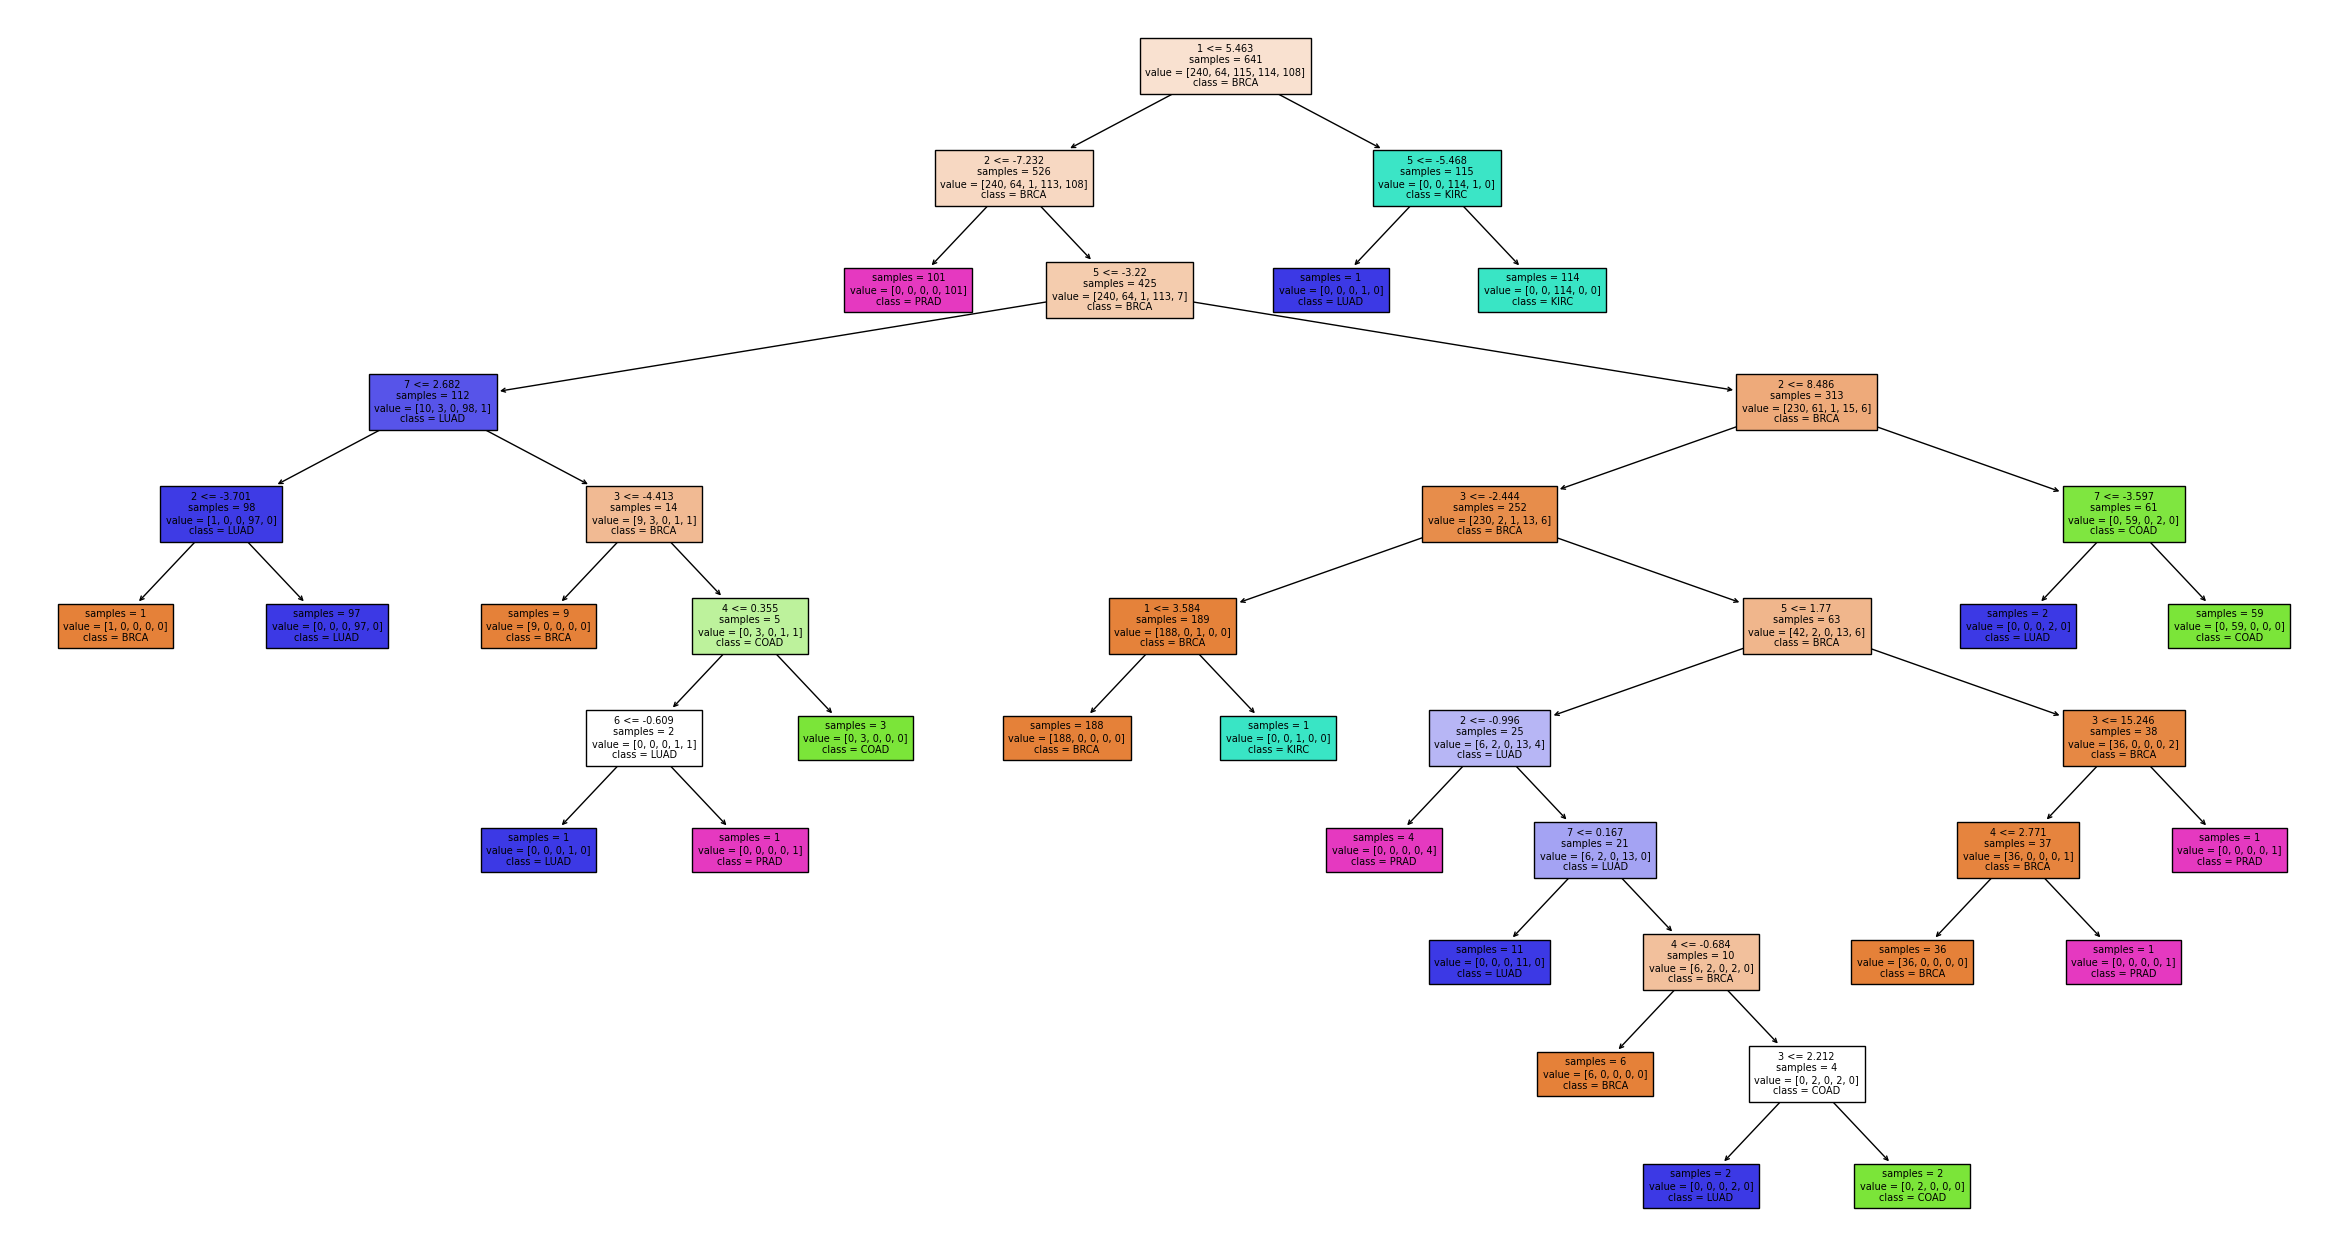

In [25]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(30, 16))

print(f"Profundidad del árbol: {clf.get_depth()}")
print(f"Número de nodos terminales: {clf.get_n_leaves()}")

plot = plot_tree(
            decision_tree = clf,
            feature_names = range(1,8),
            class_names   = label_encoder.classes_,
            filled        = True,
            impurity      = False,
            fontsize      = 7,
            ax            = ax
       )
plt.savefig('tree.eps',format='eps',bbox_inches = "tight")

**7. Muestre el árbol en formato de texto.**

In [26]:
texto_modeloe = export_text(
                    decision_tree = clf,
                    feature_names = range(1,8)
               )
print(texto_modeloe)

|--- 1 <= 5.46
|   |--- 2 <= -7.23
|   |   |--- class: 4
|   |--- 2 >  -7.23
|   |   |--- 5 <= -3.22
|   |   |   |--- 7 <= 2.68
|   |   |   |   |--- 2 <= -3.70
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- 2 >  -3.70
|   |   |   |   |   |--- class: 3
|   |   |   |--- 7 >  2.68
|   |   |   |   |--- 3 <= -4.41
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- 3 >  -4.41
|   |   |   |   |   |--- 4 <= 0.36
|   |   |   |   |   |   |--- 6 <= -0.61
|   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |--- 6 >  -0.61
|   |   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |--- 4 >  0.36
|   |   |   |   |   |   |--- class: 1
|   |   |--- 5 >  -3.22
|   |   |   |--- 2 <= 8.49
|   |   |   |   |--- 3 <= -2.44
|   |   |   |   |   |--- 1 <= 3.58
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- 1 >  3.58
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |--- 3 >  -2.44
|   |   |   |   |   |--- 5 <= 1.77
|   |   |   |   |   |   |--- 2 <= -1.00
|   |  

**8. Revise la importancia de los predictores.**

In [27]:
pd.options.display.max_rows = 150
importancia_predictores = pd.DataFrame(
                            {'predictor': range(1,8),
                             'importancia': clf.feature_importances_}
                            )
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen imp

,predictor,importancia
1,2,0.399605
0,1,0.305513
4,5,0.176617
6,7,0.052701
2,3,0.048987
3,4,0.015147
5,6,0.001429


**9. Compare la clasificación real contra la predicción del modelo (Grafico en 2d de los
puntos usando colores para indicar el tipo de cáncer)
*nota: del gráfico 2d del modelo anterior solo cambia:**

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


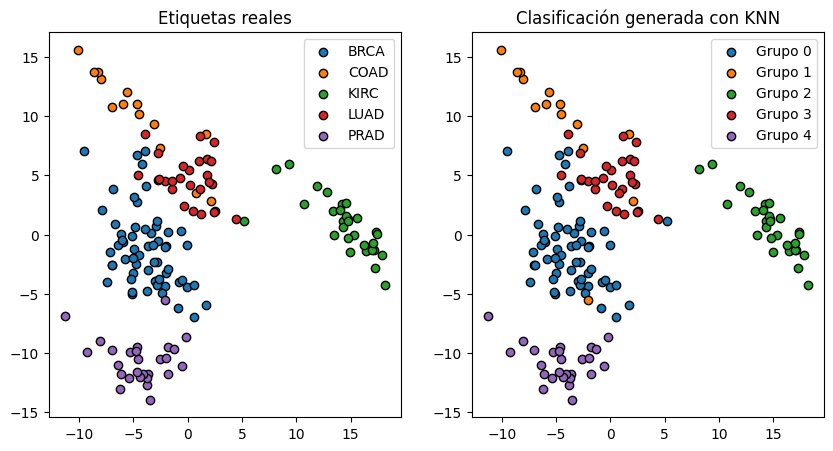

In [28]:
# Clasificación con el modelo KNN
# ==============================================================================
true_labels_test=true_labels[642:800]

# Representación gráfica: grupos originales vs clusters creados
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Grupos originales
for i in np.unique(true_labels):
    ax[0].scatter(
        x = Xtest[true_labels_test == i, 0],
        y = Xtest[true_labels_test == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= label_encoder.classes_[i]
    )
ax[0].set_title('Etiquetas reales')
ax[0].legend();

for i in np.unique(y_pred):
    ax[1].scatter(
        x = Xtest[y_pred == i, 0],
        y = Xtest[y_pred == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )

ax[1].set_title('Clasificación generada con KNN')
ax[1].legend();


**10.Realice una búsqueda por validación cruzada con el objeto GridSearchCV para
analizar si usando una poda del árbol el modelo mejora. Use los siguientes
parámetros:
param_grid = {'max_features': [None,'log2', 'sqrt'],
'ccp_alpha': [0,0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, .01],
 'max_depth' : [3,4,5, 6, 7, 8, 9,10,11,12,13,14,15],
 'criterion' :['gini','entropy',"log_loss"]
 }**

<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()
/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:792: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = leg.legendHandles


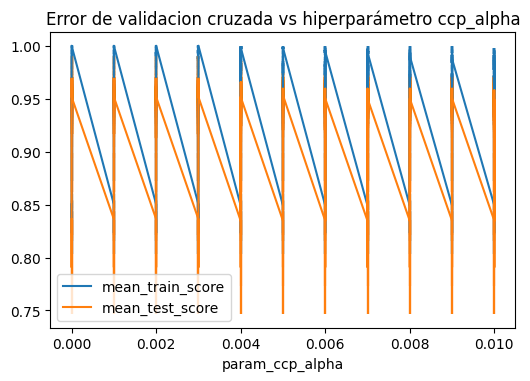

In [29]:
param_grid = {'max_features': [None,'log2', 'sqrt'],
'ccp_alpha': [0,0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, .01],
 'max_depth' : [3,4,5, 6, 7, 8, 9,10,11,12,13,14,15],
 'criterion' :['gini','entropy',"log_loss"]
 }

# Búsqueda por validación cruzada
grid = GridSearchCV(
        # El árbol se crece al máximo posible antes de aplicar el pruning
        estimator = DecisionTreeClassifier(
                            random_state      = 456
                       ),
        param_grid = param_grid,
        scoring    = 'accuracy',
        refit      = True,
        return_train_score = True
      )

grid.fit(Xtrain, Ytrain)

fig, ax = plt.subplots(figsize=(6, 3.84))
scores = pd.DataFrame(grid.cv_results_)
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score', ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax)
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha");

**11.Revise cual fue la mejor configuración encontrada (grid.best_params_) y muestre
su profundidad y número de hojas.**

In [30]:
# Mejor valor ccp_alpha encontrado
# ------------------------------------------------------------------------------
grid.best_params_

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


{'ccp_alpha': 0, 'criterion': 'gini', 'max_depth': 8, 'max_features': None}

**12.Repita los pasos 5-9 con el modelo actual.**

In [31]:
# Model Accuracy, how often is the classifier correct?
print("Exactitud:",accuracy_score(Ytest, y_pred))
score = r2_score(Ytest, y_pred)
mae = mean_absolute_error(Ytest, y_pred)
mse = mean_squared_error(Ytest, y_pred)
rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print("Rendimiento en pruebas:")
print("-------------------------------")
print('r2_score is', score)
print('MAE is ', mae)
print('MSE is ', mse)
print('RMSE is ',rmse)

Exactitud: 0.9810126582278481
Rendimiento en pruebas:
-------------------------------
r2_score is 0.9538717821017019
MAE is  0.04430379746835443
MSE is  0.10759493670886076
RMSE is  0.328016671388606


In [32]:
# Estructura del árbol final
# ------------------------------------------------------------------------------
modelo_final = grid.best_estimator_
print(f"Profundidad del árbol: {modelo_final.get_depth()}")
print(f"Número de nodos terminales: {modelo_final.get_n_leaves()}")

Profundidad del árbol: 8
Número de nodos terminales: 21


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [33]:
# Error de test del modelo final
#-------------------------------------------------------------------------------
predicciones = modelo_final.predict(X = Xtest)

accuracy = accuracy_score(
            y_true    = Ytest,
            y_pred    = predicciones,
            normalize = True
           )
print(f"El accuracy de test es: {100 * accuracy} %")

El accuracy de test es: 97.46835443037975 %


In [34]:
# Model Accuracy, how often is the classifier correct?
print("Exactitud:",accuracy_score(Ytest, predicciones))
score = r2_score(Ytest, predicciones)
mae = mean_absolute_error(Ytest, predicciones)
mse = mean_squared_error(Ytest, predicciones)
rmse = np.sqrt(mean_squared_error(Ytest, predicciones))
print("Rendimiento en pruebas:")
print("-------------------------------")
print('r2_score is', score)
print('MAE is ', mae)
print('MSE is ', mse)
print('RMSE is ',rmse)

Exactitud: 0.9746835443037974
Rendimiento en pruebas:
-------------------------------
r2_score is 0.9511583575194491
MAE is  0.05063291139240506
MSE is  0.11392405063291139
RMSE is  0.3375263702778072


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [35]:
# Error de test del modelo
#-------------------------------------------------------------------------------
print("Matriz de confusión")
print("-------------------")
confusion_matrix(
    y_true    = Ytest,
    y_pred    = predicciones
)

Matriz de confusión
-------------------


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array([[59,  0,  0,  0,  0],
       [ 1, 12,  0,  1,  0],
       [ 1,  0, 30,  0,  0],
       [ 0,  0,  0, 27,  0],
       [ 0,  1,  0,  0, 26]])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Profundidad del árbol: 8
Número de nodos terminales: 21


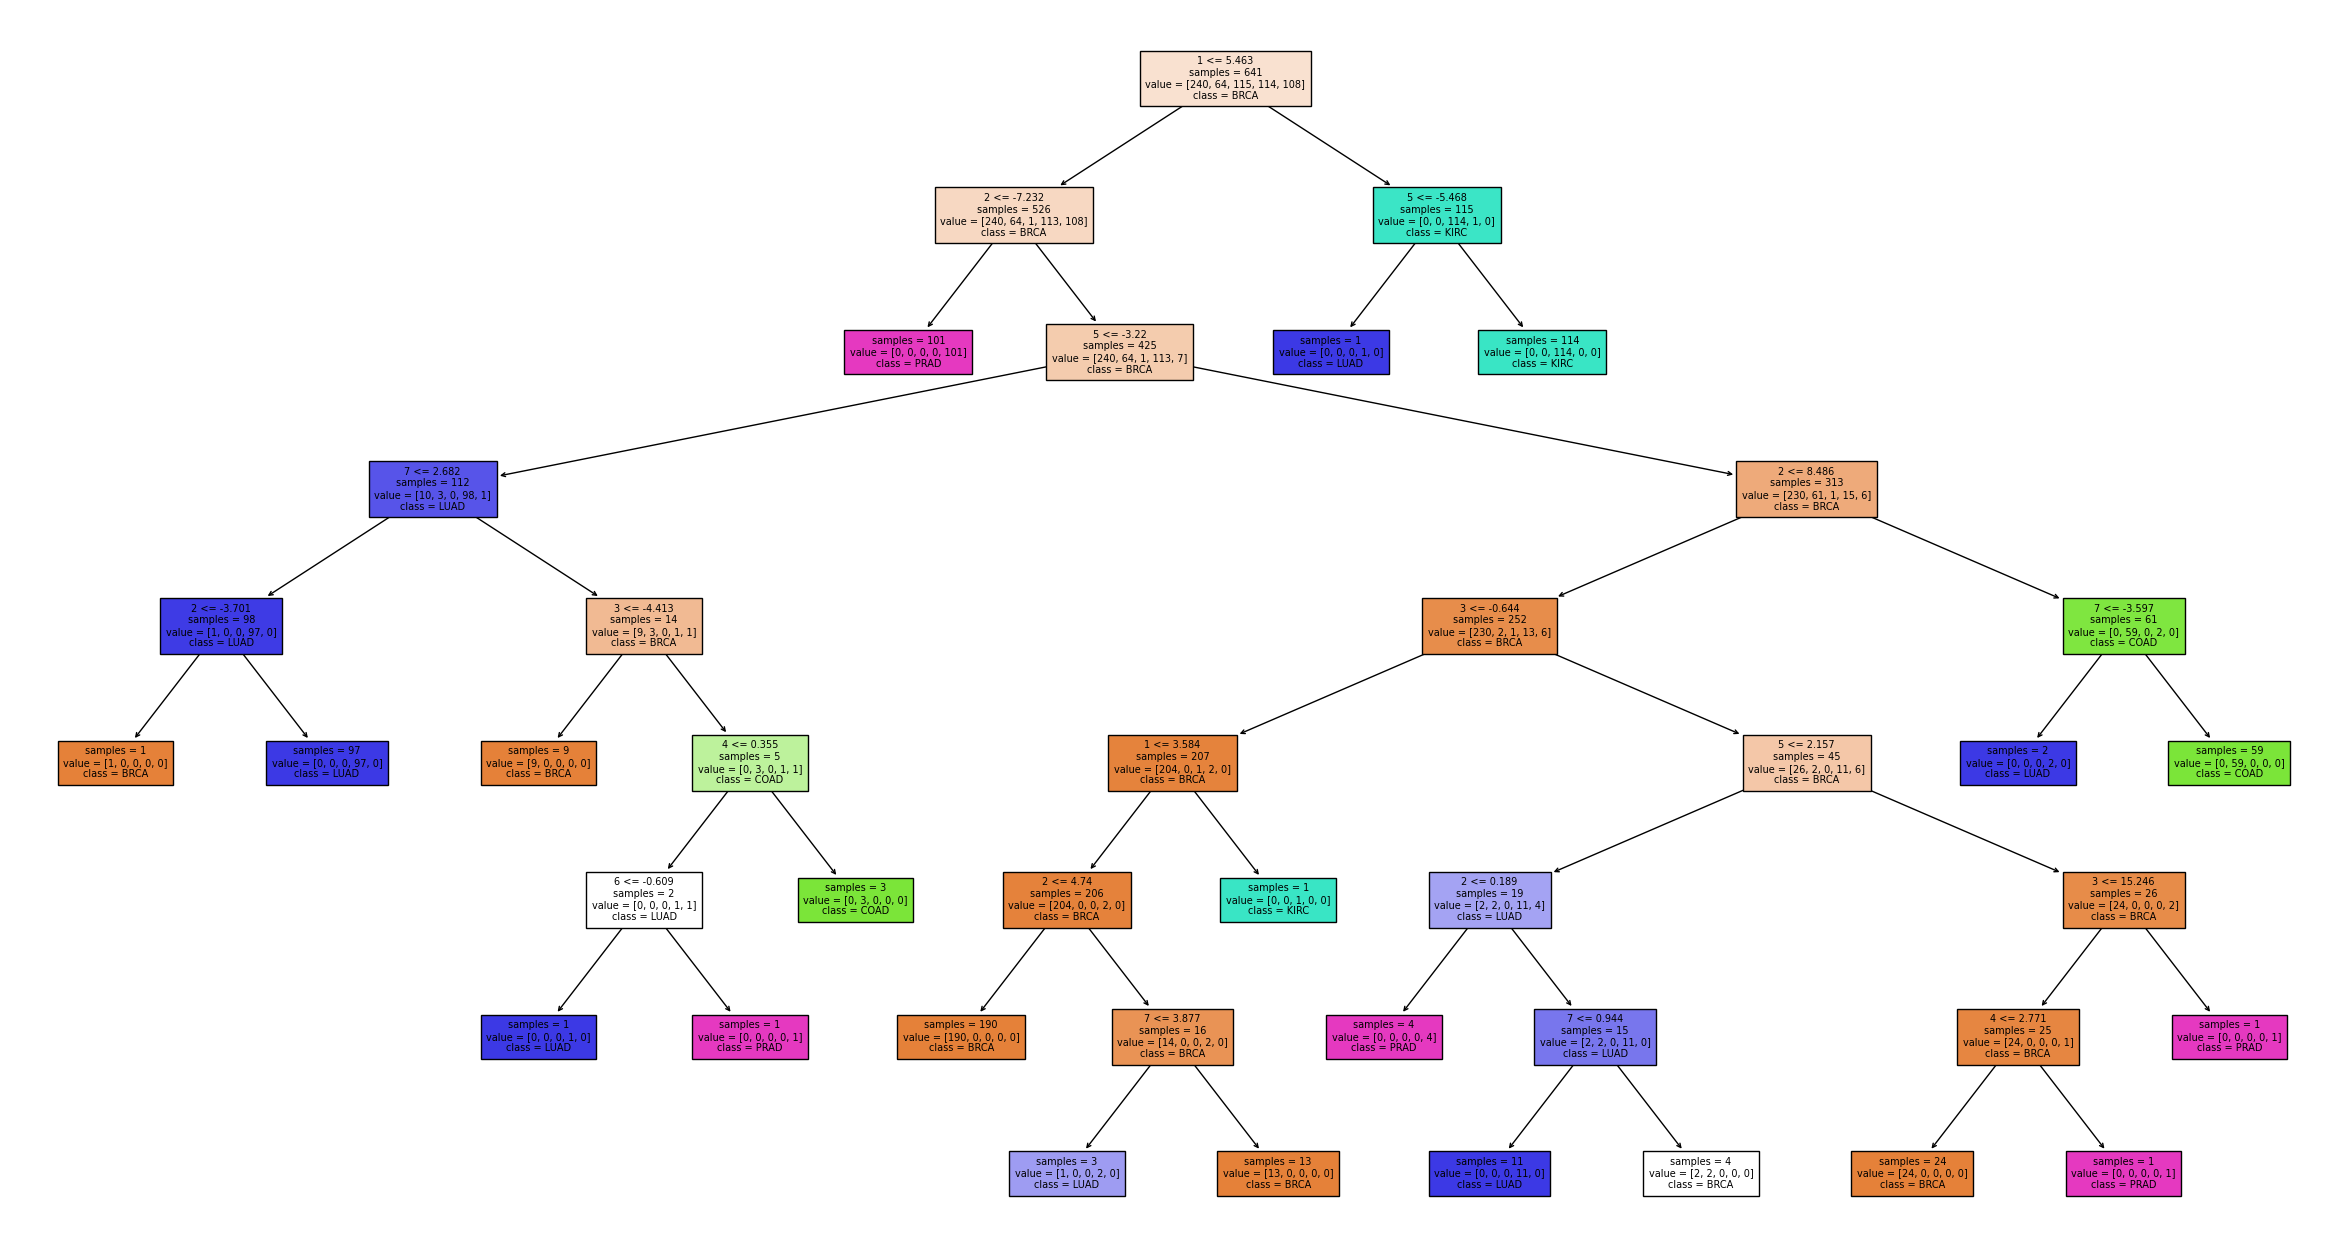

In [36]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(30, 16))

print(f"Profundidad del árbol: {modelo_final.get_depth()}")
print(f"Número de nodos terminales: {modelo_final.get_n_leaves()}")

plot = plot_tree(
            decision_tree = modelo_final,
            feature_names = range(1,8),
            class_names   = label_encoder.classes_,
            filled        = True,
            impurity      = False,
            fontsize      = 7,
            ax            = ax
       )
plt.savefig('tree.eps',format='eps',bbox_inches = "tight")

In [37]:
texto_modeloe = export_text(
                    decision_tree = modelo_final,
                    feature_names = range(1,8)
               )
print(texto_modeloe)

|--- 1 <= 5.46
|   |--- 2 <= -7.23
|   |   |--- class: 4
|   |--- 2 >  -7.23
|   |   |--- 5 <= -3.22
|   |   |   |--- 7 <= 2.68
|   |   |   |   |--- 2 <= -3.70
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- 2 >  -3.70
|   |   |   |   |   |--- class: 3
|   |   |   |--- 7 >  2.68
|   |   |   |   |--- 3 <= -4.41
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- 3 >  -4.41
|   |   |   |   |   |--- 4 <= 0.36
|   |   |   |   |   |   |--- 6 <= -0.61
|   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |--- 6 >  -0.61
|   |   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |--- 4 >  0.36
|   |   |   |   |   |   |--- class: 1
|   |   |--- 5 >  -3.22
|   |   |   |--- 2 <= 8.49
|   |   |   |   |--- 3 <= -0.64
|   |   |   |   |   |--- 1 <= 3.58
|   |   |   |   |   |   |--- 2 <= 4.74
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- 2 >  4.74
|   |   |   |   |   |   |   |--- 7 <= 3.88
|   |   |   |   |   |   |   |   |--- class: 3
|   |   |   |   

In [38]:
pd.options.display.max_rows = 150
importancia_predictores = pd.DataFrame(
                            {'predictor': range(1,8),
                             'importancia': modelo_final.feature_importances_}
                            )
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
1,2,0.427405
0,1,0.255811
4,5,0.220726
6,7,0.054519
2,3,0.031752
3,4,0.007713
5,6,0.002073


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


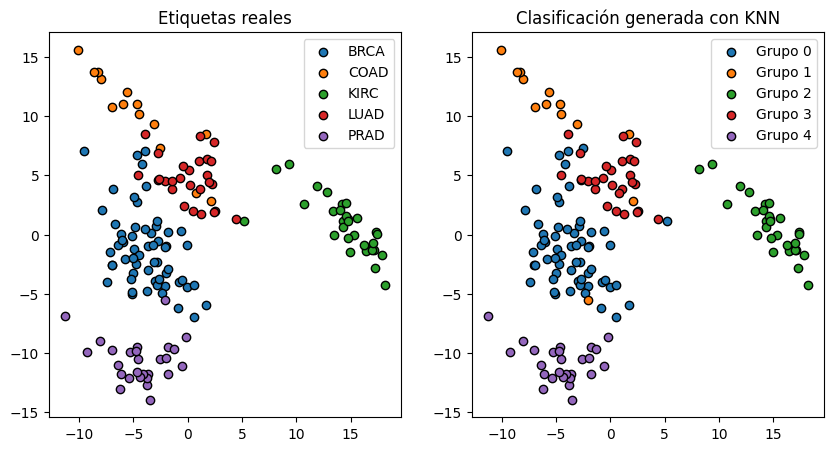

In [39]:
# Clasificación con el modelo KNN
# ==============================================================================
true_labels_test=true_labels[642:800]

# Representación gráfica: grupos originales vs clusters creados
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Grupos originales
for i in np.unique(true_labels):
    ax[0].scatter(
        x = Xtest[true_labels_test == i, 0],
        y = Xtest[true_labels_test == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= label_encoder.classes_[i]
    )
ax[0].set_title('Etiquetas reales')
ax[0].legend();

for i in np.unique(predicciones):
    ax[1].scatter(
        x = Xtest[predicciones == i, 0],
        y = Xtest[predicciones == i, 1],
        c = plt.rcParams['axes.prop_cycle'].by_key()['color'][i],
        marker    = 'o',
        edgecolor = 'black',
        label= f"Grupo {i}"
    )

ax[1].set_title('Clasificación generada con KNN')
ax[1].legend();

/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:792: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = leg.legendHandles


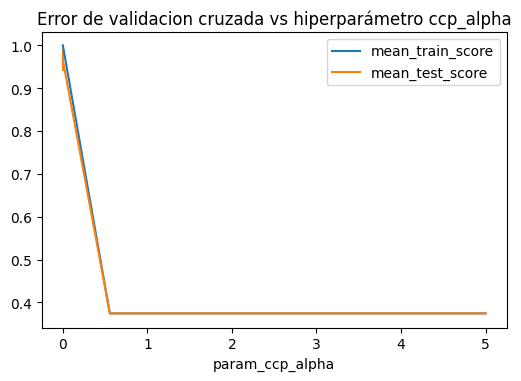

In [40]:
# Post pruning (const complexity pruning) por validación cruzada
# ------------------------------------------------------------------------------
# Valores de ccp_alpha evaluados
param_grid = {'ccp_alpha':np.linspace(0, 5, 10)}

# Búsqueda por validación cruzada
grid = GridSearchCV(
        # El árbol se crece al máximo posible antes de aplicar el pruning
        estimator = DecisionTreeClassifier(
                            criterion         ="gini",
                            max_depth         = None,
                            min_samples_split = 2,
                            min_samples_leaf  = 1,
                            random_state      = 456
                       ),
        param_grid = param_grid,
        scoring    = 'accuracy',
        cv         = 10,
        refit      = True,
        return_train_score = True
      )

grid.fit(Xtrain, Ytrain)

fig, ax = plt.subplots(figsize=(6, 3.84))
scores = pd.DataFrame(grid.cv_results_)
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score', ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax)
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha");